# Bias-Corrected ARIMA Model and Final Validation

## Purpose
Corrects the systematic prediction bias identified in `arima_residuals.ipynb`, finalises the **ARIMA(1,0,0)** model, and evaluates it against the held-out validation set. The trained model and bias constant are persisted to disk for production use.

The bias is estimated as the mean of the training residuals and added to every forecast. The ACF and PACF of the corrected residuals are then inspected to confirm no autocorrelation structure remains.

## Inputs
- `data/dataset.csv` — Training dataset (93 monthly observations)
- `data/validation.csv` — Held-out validation set (12 observations, never seen during development)

## Outputs
- `models/model.pkl` — Serialised `ARIMAResults` object (final fit on full training history)
- `models/model_bias.npy` — NumPy array containing the scalar bias correction constant
- Inline: training RMSE, corrected residual statistics, ACF/PACF plots, and final validation RMSE with a plot of predictions vs actuals

In [1]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

## Differencing and Inverse-Difference Helpers

In [2]:
# create a differenced series
def difference(dataset, interval=1):
    diff = list()
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return diff

In [3]:
# invert differenced value
def inverse_difference(history, yhat, interval=1):
    return yhat + history[-interval]

## Load Training Data

In [4]:
series = pd.read_csv('data/dataset.csv', index_col=0, parse_dates=True).iloc[:, 0]
series.head()

Month
1964-01-01    2815
1964-02-01    2672
1964-03-01    2755
1964-04-01    2721
1964-05-01    2946
Name: Sales, dtype: int64

## Train / Test Split

In [5]:
# prepare data
X = series.values
X = X.astype('float64')
train_size = int(len(X) * 0.50)
train, test = X[0:train_size], X[train_size:]

## Walk-Forward Validation with Bias Correction

The bias constant (`165.904728`) was estimated as the mean of the residuals from `arima_residuals.ipynb`. It is added to every inverse-differenced forecast before the prediction is recorded.

`trend='n'` suppresses statsmodels' internal intercept term — the bias is managed explicitly rather than being absorbed into the model's constant, giving full control over the correction value.

In [6]:
# walk-forward validation
history = [x for x in train]
predictions = list()
bias = 165.904728
for i in range(len(test)):
    # difference data
    months_in_year = 12
    diff = difference(history, months_in_year)
    # predict
    model = ARIMA(diff, order=(1,0,0), trend='n')
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    yhat = bias + inverse_difference(history, yhat, months_in_year)
    predictions.append(yhat)
    # observation
    obs = test[i]
    history.append(obs)

## Training Set RMSE

The in-sample RMSE after bias correction. Compare this to the uncorrected ARIMA and persistence baseline RMSEs to quantify the improvement.

In [7]:
# report performance
rmse = sqrt(mean_squared_error(test, predictions))
print('RMSE: %.3f' % rmse)

RMSE: 935.439


## Corrected Residual Summary Statistics

The residual mean should now be near zero, confirming the bias has been successfully removed.

In [8]:
# errors
residuals = [test[i]-predictions[i] for i in range(len(test))]
residuals = pd.DataFrame(residuals)
print(residuals.describe())

                 0
count    47.000000
mean    -32.020584
std     944.997950
min   -2615.629130
25%    -426.077077
50%      11.948796
75%     479.568183
max    2142.878697


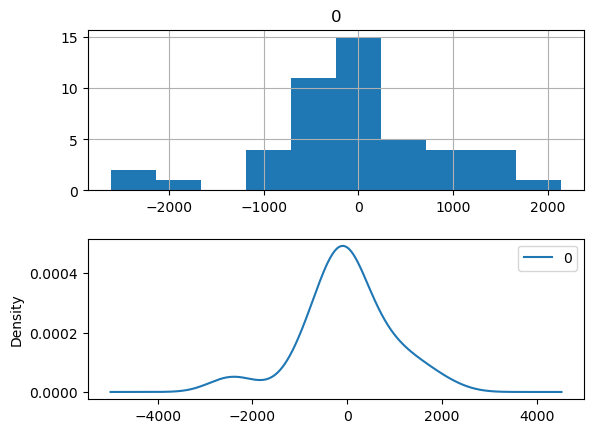

In [9]:
# plot
plt.figure();
plt.subplot(211);
residuals.hist(ax=plt.gca());
plt.subplot(212);
residuals.plot(kind='kde', ax=plt.gca());

## Residual ACF and PACF

Inspect the autocorrelation structure of the corrected residuals. No significant spikes beyond the confidence bands would indicate the model has captured the available signal and the residuals are consistent with white noise.

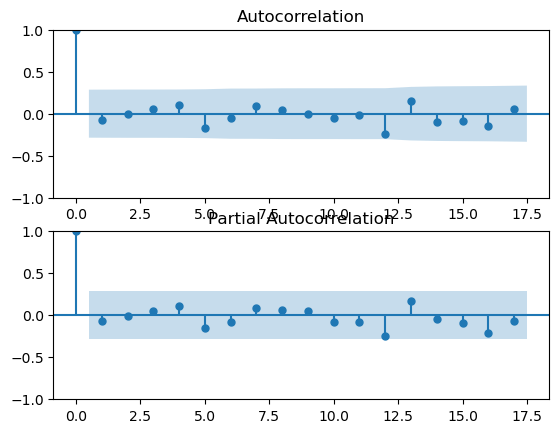

In [10]:
# plot
plt.figure();
plt.subplot(211);
plot_acf(residuals, ax=plt.gca());
plt.subplot(212);
plot_pacf(residuals, ax=plt.gca());

## Persist Model and Bias Constant

Serialise the final fitted `ARIMAResults` object to `models/model.pkl` and save the bias scalar to `models/model_bias.npy`. These two artefacts together constitute the complete deployable model.

In [11]:
model_fit.save('models/model.pkl')
np.save('models/model_bias.npy', [bias])

## Load Model and Generate Next-Step Forecast

Demonstrate the complete prediction pipeline using the saved artefacts: load the model and bias, produce a one-step-ahead forecast on the differenced series, invert the seasonal difference, and apply the bias correction. This is the exact code path that would be used in production.

In [12]:
model_fit = ARIMAResults.load('models/model.pkl')
bias = float(np.load('models/model_bias.npy')[0])
yhat = float(model_fit.forecast()[0])
yhat = bias + inverse_difference(series.values, yhat, months_in_year)
print('Predicted: %.3f' % yhat)

Predicted: 6564.640


## Load Held-Out Validation Data

Load the 12-month validation set that was held back at the very start of the project. This is the first and only time validation data is used — it has had no influence on any modelling decisions.

In [13]:
X = series.values.astype('float64')
history = [x for x in X]
validation = pd.read_csv('data/validation.csv', index_col=0, parse_dates=True).iloc[:, 0]
y = validation.values.astype('float32')
validation.head()

Month
1971-10-01     6981
1971-11-01     9851
1971-12-01    12670
1972-01-01     4348
1972-02-01     3564
Name: Sales, dtype: int64

## First Validation Forecast (from Saved Model)

Generate the first validation forecast using the persisted model object, then append the true observation to history. Subsequent forecasts re-fit the model to keep it current, matching the walk-forward protocol used during development.

In [14]:
predictions = list()
yhat = float(model_fit.forecast()[0])
yhat = bias + inverse_difference(history, yhat, months_in_year)
predictions.append(yhat)
history.append(y[0])
print('>Predicted=%.3f, Expected=%.3f' % (yhat, y[0]))

>Predicted=6564.640, Expected=6981.000


## Rolling Validation Forecasts

Walk forward through the remaining 11 validation observations, re-fitting ARIMA(1,0,0) at each step with the full updated history and applying the bias correction to every forecast.

In [15]:
# rolling forecasts
for i in range(1, len(y)):
    # difference data
    months_in_year = 12
    diff = difference(history, months_in_year)
    # predict
    model = ARIMA(diff, order=(1,0,0), trend='n')
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    yhat = bias + inverse_difference(history, yhat, months_in_year)
    predictions.append(yhat)
    # observation
    obs = y[i]
    history.append(obs)
    print('>Predicted=%.3f, Expected=%.3f' % (yhat, obs))

>Predicted=10187.698, Expected=9851.000
>Predicted=13244.796, Expected=12670.000
>Predicted=3969.483, Expected=4348.000
>Predicted=3459.398, Expected=3564.000
>Predicted=4580.342, Expected=4577.000
>Predicted=4935.202, Expected=4788.000
>Predicted=5211.828, Expected=4618.000
>Predicted=4914.471, Expected=5312.000
>Predicted=4937.486, Expected=4298.000
>Predicted=1720.036, Expected=1413.000
>Predicted=6039.698, Expected=5877.000


## Final Validation Performance

Compute and report the RMSE on the held-out validation set — this is the definitive measure of out-of-sample model performance. Plot the actual validation values against the bias-corrected predictions to visually assess forecast quality across the full validation horizon.

RMSE: 390.870


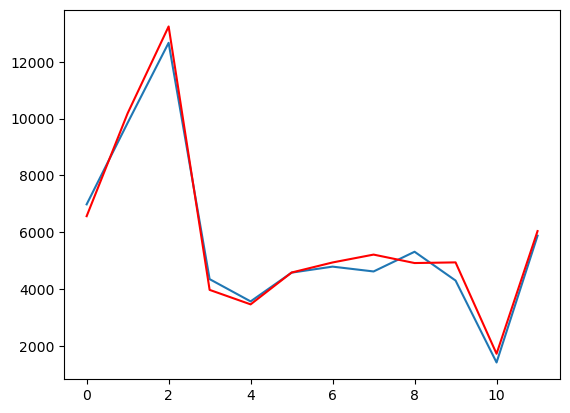

In [16]:
# report performance
rmse = sqrt(mean_squared_error(y, predictions))
print('RMSE: %.3f' % rmse)
plt.plot(y);
plt.plot(predictions, color='red');